In [1]:
!apt-get update -qq
!apt-get install -y lammps python3-lammps


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-mathjax javascript-common lammps-data lammps-doc lammps-examples
  libdouble-conversion3 libgl2ps1.4 libglew2.2 libjs-mathjax libjs-underscore
  libkim-api2 liblammps-dev liblammps0t64 libpnetcdf0d libtbb12 libtbbbind-2-5
  libtbbmalloc2 libvoro++1 libvtk9.1t64 python3-mpi4py
Suggested packages:
  apache2 | lighttpd | httpd openkim-models glew-utils fonts-mathjax-extras
  fonts-stix libjs-mathjax-doc vtk9-doc vtk9-examples
The following NEW packages will be installed:
  fonts-mathjax javascript-common lammps lammps-data lammps-doc
  lammps-examples libdouble-conversion3 libgl2ps1.4 libglew2.2 libjs-mathjax
  libjs-underscore libkim-api2 liblammp

In [2]:
%%writefile lJ_melt.in

units lj
atom_style atomic

lattice fcc 0.8442
region box block 0 10 0 10 0 10

create_box 1 box
create_atoms 1 box

mass 1 1.0

pair_style lj/cut 2.5
pair_coeff 1 1 1.0 1.0 2.5

velocity all create 3.0 87287

neighbor 0.3 bin
neigh_modify every 20 delay 0 check yes

fix 1 all nve

compute msd_all all msd
fix msd_out all ave/time 50 1 50 &
    c_msd_all[1] c_msd_all[2] c_msd_all[3] c_msd_all[4] &
    file msd.dat

# RDF
compute rdf_all all rdf 200
fix rdf_out all ave/time 50 1 50 c_rdf_all[*] &
    file rdf.dat mode vector

thermo 50
thermo_style custom step temp pe etotal press

run 1000

Writing lJ_melt.in


In [3]:
!lmp -in lJ_melt.in

LAMMPS (7 Feb 2024 - Update 1)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Lattice spacing in x,y,z = 1.6795962 1.6795962 1.6795962
Created orthogonal box = (0 0 0) to (16.795962 16.795962 16.795962)
  1 by 1 by 1 MPI processor grid
Created 4000 atoms
  using lattice units in orthogonal box = (0 0 0) to (16.795962 16.795962 16.795962)
  create_atoms CPU = 0.001 seconds
Generated 0 of 0 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update: every = 20 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 2.8
  ghost atom cutoff = 2.8
  binsize = 1.4, bins = 12 12 12
  2 neighbor lists, perpetual/occasional/extra = 1 1 0
  (1) pair lj/cut, perpetual
      attributes: half, newton on
      pair build: half/bin/atomonly/newton
      stencil: half/bin/3d
      bin: standard
  (2) compute rdf, occasional, copy from (1)
      att

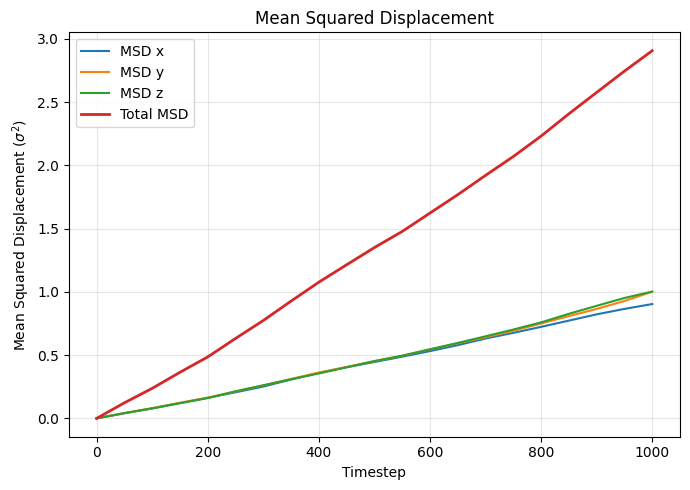

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Read LAMMPS MSD output
data = np.loadtxt("msd.dat", comments="#")

step = data[:, 0]
msd_x = data[:, 1]
msd_y = data[:, 2]
msd_z = data[:, 3]
msd_total = data[:, 4]

# Plot
plt.figure(figsize=(7, 5))

plt.plot(step, msd_x, label="MSD x")
plt.plot(step, msd_y, label="MSD y")
plt.plot(step, msd_z, label="MSD z")
plt.plot(step, msd_total, label="Total MSD", linewidth=2)

plt.xlabel("Timestep")
plt.ylabel(r"Mean Squared Displacement ($\sigma^2$)")
plt.title("Mean Squared Displacement")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("msd.png", dpi=300)
plt.show()

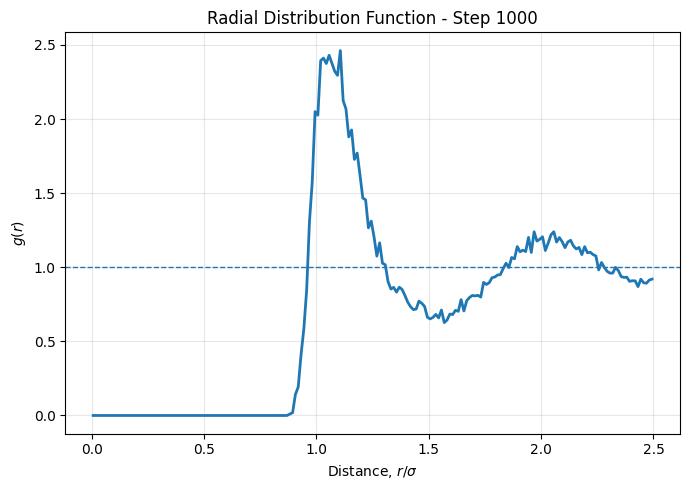

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

filename = "rdf.dat"

blocks = []

with open(filename, "r") as f:
    lines = f.readlines()

i = 0

while i < len(lines):

    line = lines[i].strip()

    if not line or line.startswith("#"):
        i += 1
        continue

    parts = line.split()

    if len(parts) == 2:
        try:
            timestep = int(parts[0])
            nrows = int(parts[1])

            block = []

            for j in range(i + 1, i + 1 + nrows):
                values = list(map(float, lines[j].split()))
                block.append(values)

            blocks.append((timestep, np.array(block)))

            i += nrows + 1
            continue

        except ValueError:
            pass

    i += 1


if len(blocks) == 0:
    raise RuntimeError("No RDF blocks found in rdf.dat")

timestep, rdf = blocks[-1]

r = rdf[:, 1]
g_r = rdf[:, 2]


plt.figure(figsize=(7, 5))

plt.plot(r, g_r, linewidth=2)

plt.xlabel(r"Distance, $r/\sigma$")
plt.ylabel(r"$g(r)$")
plt.title(f"Radial Distribution Function - Step {timestep}")

plt.axhline(y=1.0, linestyle="--", linewidth=1)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("rdf.png", dpi=300)
plt.show()